# Feature Engineering on Titanic Dataset

## Import Required Libraries

In [19]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA


## Load the Dataset

In [20]:

df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset Overview

In [21]:

df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Separate Numerical and Categorical Columns

In [22]:

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


## Handle Missing Values

In [23]:

num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


## Encode Categorical Variables

In [24]:

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


## Remove Outliers

In [25]:

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


## Feature Scaling

In [26]:

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


## Separate Features and Target Variable

In [27]:

X = df.select_dtypes(include=['int64','float64'])
y = X['survived']
X = X.drop('survived', axis=1)


## Feature Selection

In [28]:

selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X)
X_selected.shape


(577, 9)

## Principal Component Analysis (PCA)

In [29]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)
pca.explained_variance_ratio_


array([0.35292682, 0.1993155 ])

## PCA Visualization

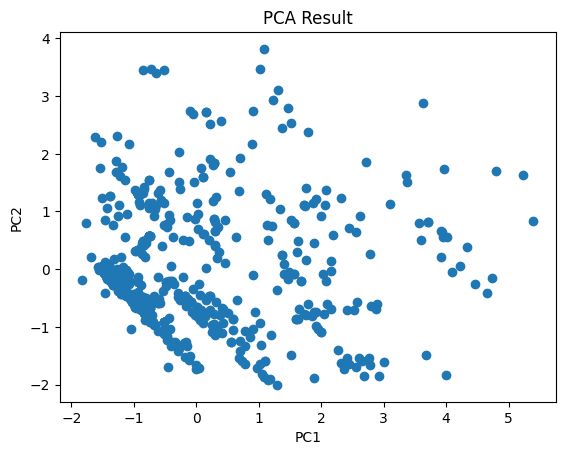

In [30]:

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Result")
plt.show()


## Conclusion

In this assignment, feature engineering techniques were applied on the Titanic dataset.
Missing values were handled using appropriate imputation methods.
Categorical variables were encoded into numerical values.
Outliers were removed using the IQR method.
Feature scaling was performed using standardization.
Feature selection was done using Variance Threshold method.
Finally, dimensionality reduction was achieved using PCA.
